# 01 · Input data for frequency analysis

Construct a sample that matches the question: annual maxima, peaks over a threshold, or a record expanded with historical bounds.

**Execution:** the default walkthrough reads checked saved app results, so it needs no live download or MCMC run.
Install this repository and the shared `bestfit-plots` package as described in the [README](../README.md).
To repeat an analysis, first build the pinned .NET runtime, set `RUN_ANALYSES = True`, and run the notebook in a fresh kernel.
The rerun retains the source priors, seeds, sampling settings and probability ordinates; receipts are saved under `output/reruns/`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "runtime-lock.json").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
import json
import pandas as pd
from IPython.display import display
from bestfit_examples.project_data import load_project
from bestfit_examples.data import input_inventory, series_inventory
from bestfit_examples.results import saved_case
from bestfit_examples.presentation import (case_metrics, case_provenance, compare_frequency,
    composite_weights, trend_ownership, uncertain_observations)
%matplotlib inline
RUN_ANALYSES = False  # True: rerun the saved analysis and its dependencies at full original settings.

## Calendar-year versus water-year maxima
Both Moose River alternatives contain 80 maxima. Their year boundaries can assign an event to different blocks;
the event timestamp remains attached to the annual index. Select the block definition before fitting a distribution.

,Input,Unit,Method,Exact,Uncertain,Interval,Threshold,Flagged low floods
0,USGS - 01134500 - Block Max - Calendar Year,Flow (cfs),BlockSeries,80,0,0,0,0
1,USGS - 01134500 - Block Max - Water Year,Flow (cfs),BlockSeries,80,0,0,0,0


,Setting,Saved choice,Alternative
0,UnitLabel,Flow (cfs),Calendar year
1,ExactDataMethod,BlockSeries,Calendar year
2,TimeBlock,CalendarYear,Calendar year
3,Threshold,0.0,Calendar year
4,Period,1,Calendar year
5,SmoothingFunction,None,Calendar year
0,UnitLabel,Flow (cfs),Water year
1,ExactDataMethod,BlockSeries,Water year
2,TimeBlock,WaterYear,Water year
3,Threshold,0.0,Water year


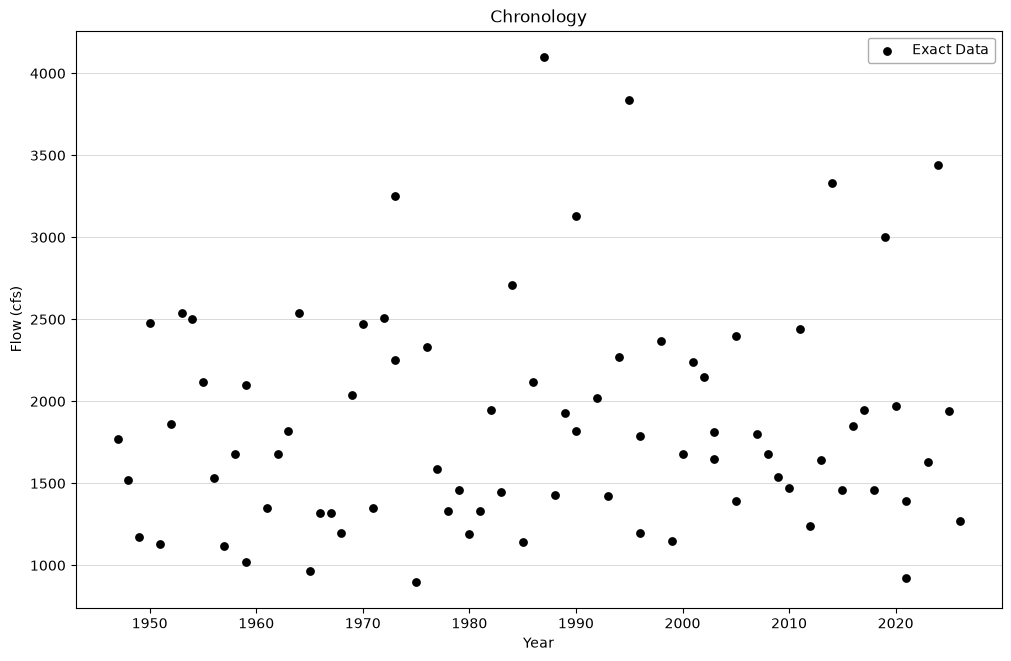

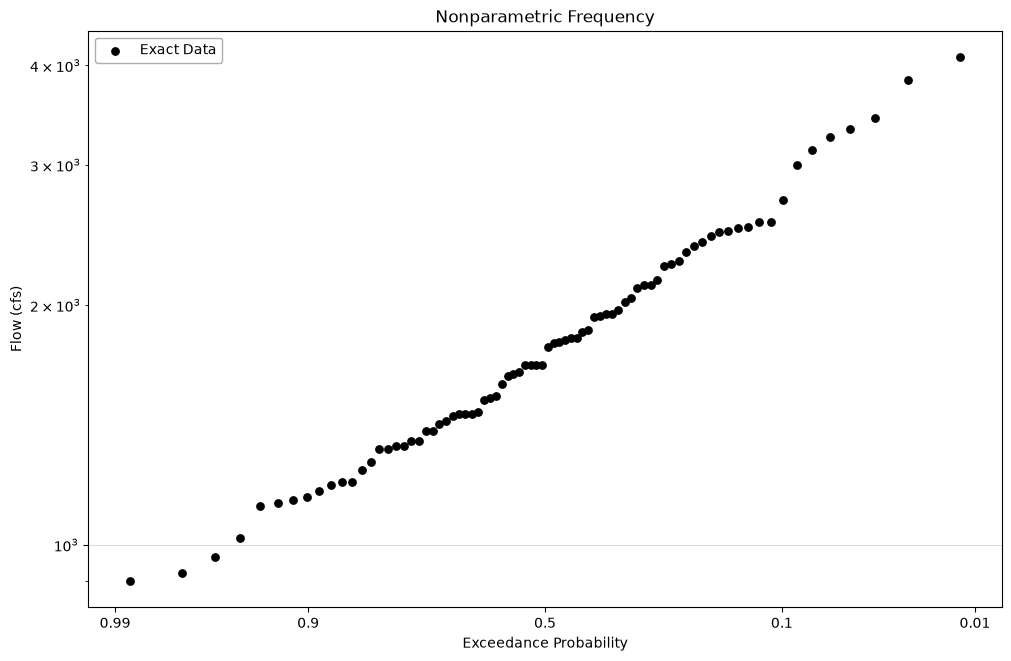

In [2]:
PROJECT = "usgs-block-max-example"
project = load_project(PROJECT)
display(input_inventory(project))
calendar_year = saved_case(PROJECT, "USGS - 01134500 - Block Max - Calendar Year")
water_year = saved_case(PROJECT, "USGS - 01134500 - Block Max - Water Year")
display(pd.concat([calendar_year.settings.assign(Alternative="Calendar year"), water_year.settings.assign(Alternative="Water year")]))
water_year.show("chronology")
water_year.show("frequency")

## Peaks over threshold
The Big Bear GHCN example uses a 1-inch threshold and retains 233 peaks over 67 observation years.
The threshold diagnostics use the same saved smoothing function and period as extraction.
Mean residual life and GPD parameter stability help examine a threshold; they do not automatically select it or establish independence.

,Input,Unit,Method,Exact,Uncertain,Interval,Threshold,Flagged low floods
0,GHCN-USC00040741-POT,depth (in),PeaksOverThresholdSeries,233,0,0,0,0


,Setting,Saved choice
0,UnitLabel,depth (in)
1,ExactDataMethod,PeaksOverThresholdSeries
2,TimeBlock,CalendarYear
3,Threshold,1.0
4,Period,2
5,SmoothingFunction,None


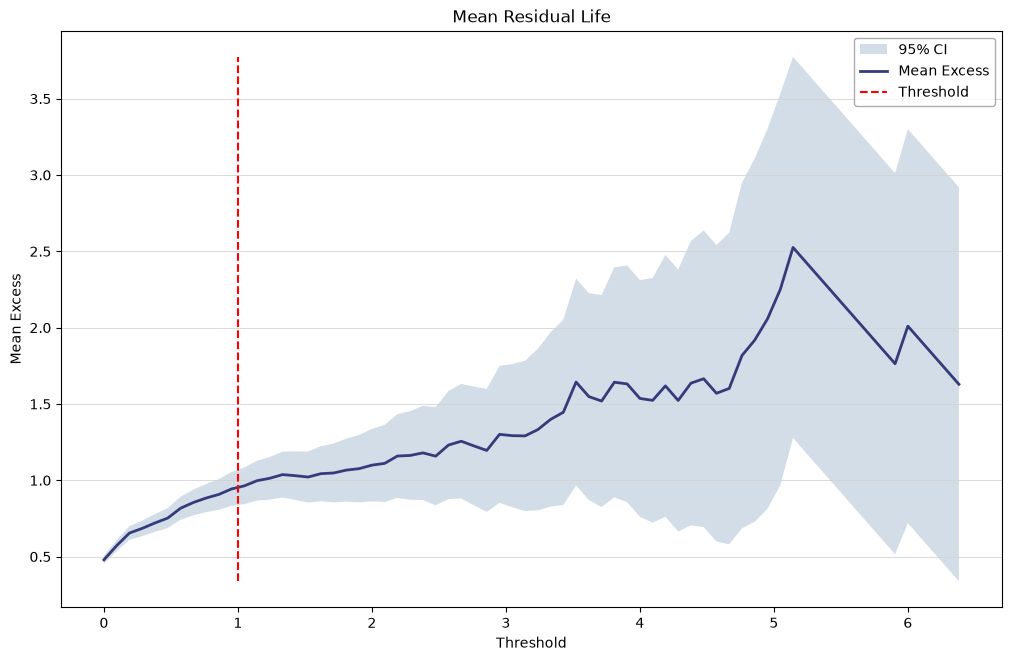

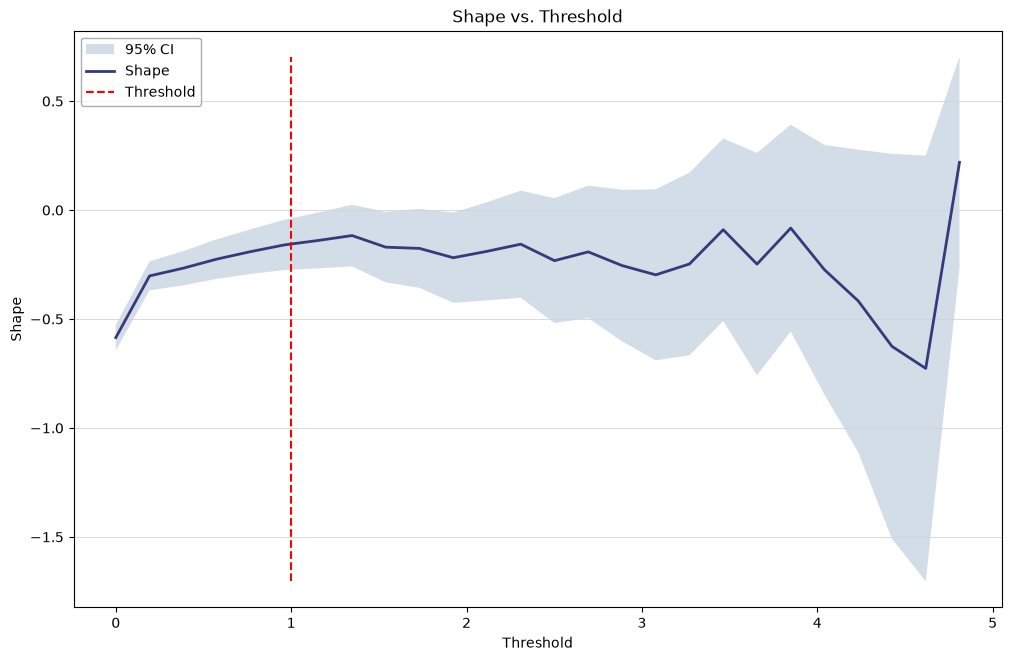

In [3]:
pot_project = load_project("ghcn-peaks-over-threshold-example")
display(input_inventory(pot_project))
pot = saved_case("ghcn-peaks-over-threshold-example", "GHCN-USC00040741-POT")
display(pot.settings)
pot.show("mean_residual_life")
pot.show("shape")

## Exact, uncertain, interval and threshold information
Exact observations, uncertain measurements, event intervals, and perception thresholds make different likelihood contributions.
A threshold window encodes what would have been noticed over a period; its duration is information, not a fabricated series of annual floods.
Viglione's temporal-expansion input illustrates historical information. Notebook 05 uses the original Bulletin 17C records;
the newer USGS annual-peak download is a different observation period and must not replace them.

,Input,Unit,Method,Exact,Uncertain,Interval,Threshold,Flagged low floods
0,Systematic (1951-2001),Peak Discharge (cms),Manual,51,0,0,0,0
1,Systematic (1951-2005),Value,Manual,55,0,0,0,0
2,Systematic (1951-2001) + Temporal Expansion,Peak Discharge (cms),Manual,51,0,3,1,0
3,Systematic (1951-2005) + Temporal Expansion,Value,Manual,55,0,3,1,0


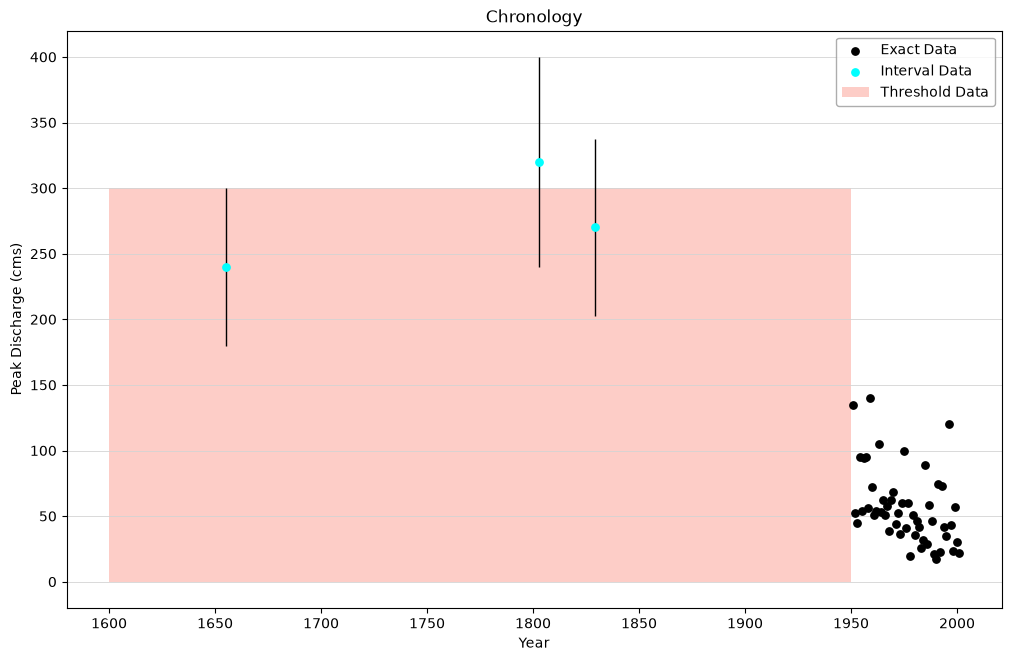

,Input,Unit,Method,Exact,Uncertain,Interval,Threshold,Flagged low floods
0,USGS - 01134500 - Peak Discharge,Value,USGSPeakDischarge,79,0,0,0,0
1,USGS - 11274500 - Peak Discharge,Value,USGSPeakDischarge,94,0,0,0,47


In [4]:
historical = load_project("viglione-et-al-2013")
display(input_inventory(historical))
expanded = saved_case("viglione-et-al-2013", "Systematic (1951-2001) + Temporal Expansion")
expanded.show("chronology")
display(input_inventory(load_project("usgs-peak-download-example")))

## Authentic uncertain observations: Sinnemahoning MOVE.3
The frozen `With Errors` input contains 79 exact observations and 25 uncertain observations.
Each uncertain year carries its saved LogNormal measurement distribution; it is not converted to an exact point before analysis.
The compact table below shows original distribution parameters directly from the project XML.

,Input,Unit,Method,Exact,Uncertain,Interval,Threshold,Flagged low floods
0,Sinnemahoning - MOVE.3 - No Errors,Flow (cfs),Manual,104,0,0,0,0
1,Sinnemahoning - MOVE.3 - With Errors,Flow (cfs),Manual,79,25,0,0,0
2,Sinnemahoning - No Extension,Flow (cfs),Manual,79,0,0,0,0


,Index,Distribution,Mu,Sigma,Plotting position
0,1914,LogNormal,4.147,0.074,0.457143
1,1915,LogNormal,4.042,0.074,0.657143
2,1916,LogNormal,4.289,0.074,0.171429
3,1917,LogNormal,4.385,0.074,0.095238
4,1918,LogNormal,4.367,0.074,0.114286


Saved uncertain observations: 25


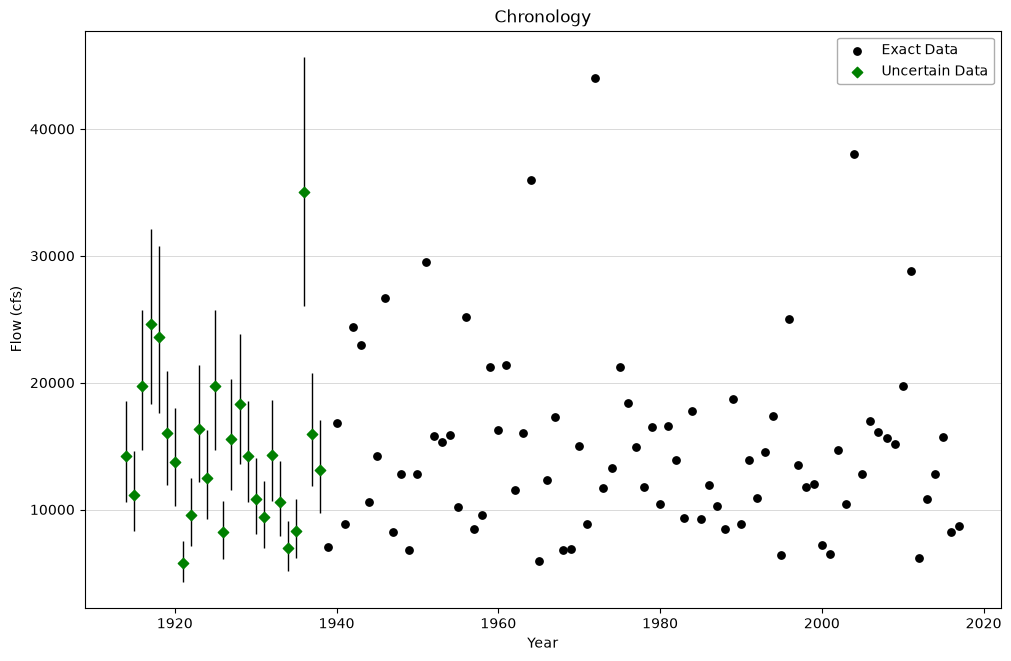

,Analysis,Origin,Source,Runtime,Settings,Receipt / result
0,Sinnemahoning - MOVE.3 - With Errors,saved-app-input,sha256:6f1832e8473f,db5807d6e3a8,saved in project snapshot,saved snapshot; no rerun receipt


In [5]:
measurement_project = load_project("sinnemahoning-move3-bayesian")
display(input_inventory(measurement_project))
uncertain = uncertain_observations(measurement_project, "Sinnemahoning - MOVE.3 - With Errors")
display(uncertain.head())
print(f"Saved uncertain observations: {len(uncertain)}")
uncertain_case = saved_case("sinnemahoning-move3-bayesian", "Sinnemahoning - MOVE.3 - With Errors", table="Input Data")
uncertain_case.show("chronology")
display(case_provenance([uncertain_case]))